Ce code permet de traiter les données effectuées avec les simulations de type "rev". Pour cela il faut faire en plus du traitement classique 2D la distinction entre la phase 1 et la phase 2. 

Ce programme parcours un dossier avec des resultats de simulations de type REV, il calcule la distance entre les premiers voisins et récupere les metadata dans le nom des fichiers.

Grace à ces données il construit un graphe permettant de mettre en forme et d'observer les résultats des simulations.

In [ ]:

import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import maximum_filter, gaussian_filter
from scipy.spatial import cKDTree
import re


def Traitement_rev(matfile):

    #On recupere les vecteurs et matrices de données stockées dans le fichier
    data = scipy.io.loadmat(matfile)

    X = data["X"]
    Y = data["Y"]
    N = data["Nsup"]
    

    #On recupere les metadonnées contenues dans le nom des fichiers
    filename = Path(matfile).stem

    match = re.search(
        r"mu0_([0-9.]+)_G0_([0-9.]+)_mu1_([0-9.]+)_G1_([0-9.]+)",
        filename
    )

    if match:
        mu = float(match.group(1))
        G = float(match.group(2))
        mu1 = float(match.group(3))
        G1 = float(match.group(4))
    else:
        mu = np.nan
        G = np.nan
        mu1 = np.nan
        G1 = np.nan

    match = re.search(
            r"Phase_([0-9.]+)",
            filename
        )
    if match:
            Phase = float(match.group(1))
            
    else:
        Phase = np.nan

        
    # Détection directe des maxima sur N ( les parametres sont ajustables, ils marchaient bien pour mes simulations)
    # léger lissage pour éliminer le bruit
    Nsmooth = gaussian_filter(N, sigma=1)

    # maximum local dans un voisinage
    neighborhood_size = 7

    local_max = (
        maximum_filter(
            Nsmooth,
            size=neighborhood_size
        ) == Nsmooth
    )

    # seuil relatif
    threshold = 0.65

    peak_mask = (
        local_max &
        (Nsmooth > threshold * Nsmooth.max())
    )

    peak_y, peak_x = np.where(peak_mask)

    peak_X = X[peak_y, peak_x]
    peak_Y = Y[peak_y, peak_x]

    peak_positions = np.column_stack(
        (peak_X, peak_Y)
    )

    if len(peak_positions) >= 2:

        tree = cKDTree(peak_positions)

        distances, _ = tree.query(
            peak_positions,
            k=2
        )

        first_neighbor_distances = distances[:, 1]

        mean_neighbor_distance = np.mean(
            first_neighbor_distances
        )

        std_neighbor_distance = np.std(
            first_neighbor_distances
        )

    else:

        mean_neighbor_distance = np.nan
        std_neighbor_distance = np.nan
    

    plt.figure(figsize=(8,8))

    plt.imshow(
        N,
        origin="lower",
        extent=[
            X.min(),
            X.max(),
            Y.min(),
            Y.max()
        ]
    )

    plt.scatter(
        peak_X,
        peak_Y,
        c="red",
        s=40
    )

    plt.title(
        f"Pics détectés\n"
        f"distance = {mean_neighbor_distance:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()

    outfile_peaks = (
        Path(matfile).with_name(
            Path(matfile).stem
            + "_peaks2D.png"
        )
    )

    plt.savefig(
        outfile_peaks,
        dpi=300
    )

    plt.close()


    return {
        "mu0": mu,
        "G0": G,
        "mu1": mu1,
        "G1": G1,
        "Phase": Phase,
        "dist" : mean_neighbor_distance,
        "N" : N,
        "X" : X,
        "Y" : Y,
    }

In [ ]:
#Parcours du dossier choisi et récuperation des résultats
dossier = "expREV0.03"
folder = Path(f"./{dossier}")

results = []

for matfile in folder.glob("*.mat"):

    print(f"Analyse : {matfile.name}")

    try:

        res = Traitement_rev(matfile)

        results.append(res)


    except Exception as e:

        print(
            f"Erreur sur {matfile.name}: {e}"
        )



Analyse : mu0_0.15_G0_0.03_mu1_0.05_G1_0.03_t_300000_cells_25000_Phase_1.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.05_G1_0.03_t_300000_cells_25000_Phase_2.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.10_G1_0.03_t_300000_cells_25000_Phase_1.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.10_G1_0.03_t_300000_cells_25000_Phase_2.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.15_G1_0.03_t_300000_cells_25000_Phase_1.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.15_G1_0.03_t_300000_cells_25000_Phase_2.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.20_G1_0.03_t_300000_cells_25000_Phase_1.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.20_G1_0.03_t_300000_cells_25000_Phase_2.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.25_G1_0.03_t_300000_cells_25000_Phase_1.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.25_G1_0.03_t_300000_cells_25000_Phase_2.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.30_G1_0.03_t_300000_cells_25000_Phase_1.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.30_G1_0.03_t_300000_cells_25000_Phase_2.mat
Analyse : mu0_0.15_G0_0.03_mu1_0.35_G1_0.03_t_300000_cells_25000_Phase_1.mat

μ phase 1 : [0.15, 0.25, 0.35, 0.4, 0.6, 0.8]
μ phase 2 : [0.05, 0.1, 0.15, 0.25, 0.35, 0.4, 0.6]


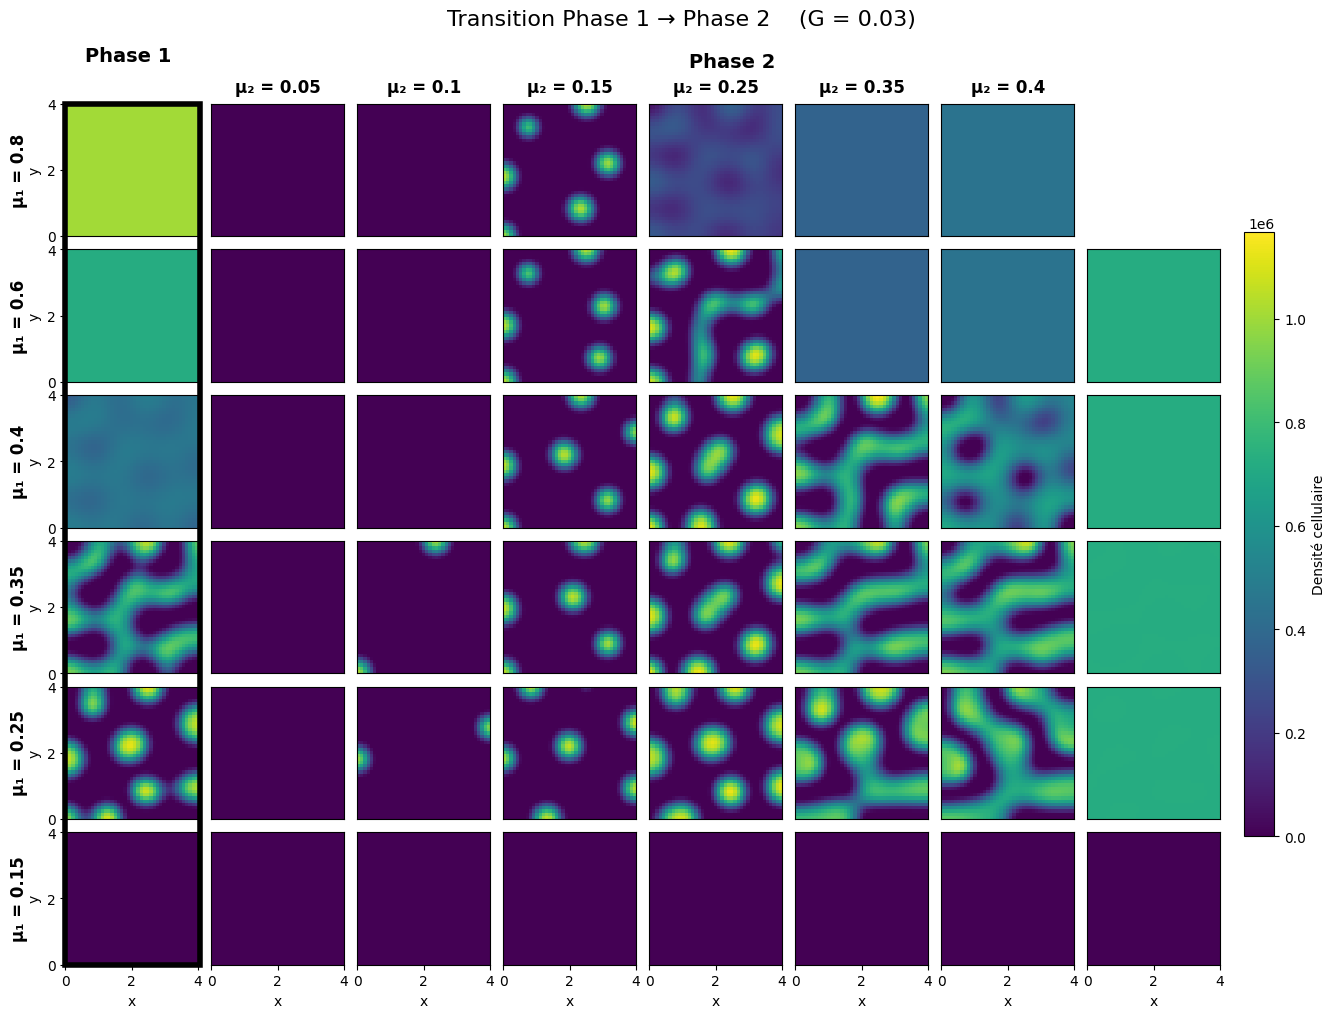

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle


# G fixé
G_fixed = 0.03

# Taille d'un panneau
panel_size = 1.5

#On peut soit récuperer toutes les données du dossier
# μ de la phase 1
mus_phase1 = np.sort(
    np.unique([
        r["mu0"]
        for r in results
        if not np.isnan(r["mu0"])
        and np.isclose(r["G0"], G_fixed)
    ])
)
# μ de la phase 2
mus_phase2 = np.sort(
    np.unique([
        r["mu1"]
        for r in results
        if not np.isnan(r["mu1"])
        and np.isclose(r["G1"], G_fixed)
    ])
)

#Ou choisir nous meme le vecteur des données qu'on souhaite afficher.
mus_phase1 = [ 0.15,  0.25,  0.35, 0.4,  0.6, 0.8]
mus_phase2 = [0.05, 0.1,  0.15,   0.25, 0.35, 0.4,  0.6 ]


n_mu1 = len(mus_phase1)
n_mu2 = len(mus_phase2)
print("μ phase 1 :", mus_phase1)
print("μ phase 2 :", mus_phase2)


#Normalisation sur toutes les données pour une echelle de couleur commune
all_profiles = np.concatenate([
    r["N"]
    for r in results
])

vmin = np.nanmin(all_profiles)
vmax = np.nanmax(all_profiles)


# Une colonne supplémentaire pour la phase 1
n_cols = n_mu2 + 1

fig_width = n_cols * panel_size + 3.5
fig_height = n_mu1 * panel_size + 1.5


fig = plt.figure(
    figsize=(fig_width, fig_height)
)


gs = fig.add_gridspec(
    n_mu1,
    n_cols,

    left=0.10,
    right=0.88,
    bottom=0.08,
    top=0.90,

    wspace=0.1,
    hspace=0.1
)


axes = np.empty(
    (n_mu1, n_cols),
    dtype=object
)


for i in range(n_mu1):

    for j in range(n_cols):

        axes[i, j] = fig.add_subplot(
            gs[i, j]
        )

#Contour autour de la premiere colonne
ax_first = axes[0, 0]
ax_last = axes[-1, 0]

# Position de la colonne dans la figure
pos_top = ax_first.get_position()
pos_bottom = ax_last.get_position()

x0 = pos_bottom.x0
y0 = pos_bottom.y0
x1 = pos_bottom.x1
y1 = pos_top.y1

rect = Rectangle(
    (x0, y0 ),
    x1 -0.003 - x0,
    y1 - y0,
    transform=fig.transFigure,
    fill=False,
    linewidth=4,
    clip_on=False
)

fig.add_artist(rect)


for i, mu0 in enumerate(mus_phase1):

    # On inverse l'ordre vertical :
    # les petits μ sont en bas
    row = n_mu1 - i - 1

    #Phase 1
    simu_phase1 = [
                r for r in results
                if r["Phase"] == 1
                and np.isclose(r["mu0"], mu0)
                and np.isclose(r["G0"], G_fixed)
            ]
    


    ax1 = axes[row, 0]


    if len(simu_phase1) == 0:

        ax1.axis("off")

    else:

        res1 = simu_phase1[0]

        N1 = res1["N"]
        X1 = res1["X"]
        Y1 = res1["Y"]


        im = ax1.imshow(
            N1,
            origin="lower",
            aspect="auto",

            extent=[
                X1.min(),
                X1.max(),
                Y1.min(),
                Y1.max()
            ],

            cmap="viridis",

            vmin=vmin,
            vmax=vmax
        )



    ax1.text(
        -0.35,
        0.5,
        f"μ₁ = {mu0:g}",

        transform=ax1.transAxes,

        rotation=90,

        va="center",
        ha="center",

        fontsize=12,
        fontweight="bold"
    )

    if i == n_mu1 - 1:
        ax1.set_title(
            "Phase 1",
            fontsize=14,
            fontweight="bold",
            pad=15
        )
    '''
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)


    ax1.spines["right"].set_linewidth(4)'''


    ax1.set_yticks([0, 2, 4])

    ax1.set_ylabel("y")


    if i == 0:

        ax1.set_xticks([0, 2, 4])
        ax1.set_xlabel("x")

    else:

        ax1.set_xticks([])

    if i == n_mu1 - 1:

        ax1.set_title(
            "Phase 1 \n",
            fontsize=14,
            fontweight="bold",
            pad=15
        )


    #Phase 2
    for j, mu1 in enumerate(mus_phase2):

        # +1 car la colonne 0 est réservée à la phase 1
        col = j + 1


        ax = axes[row, col]


        simu_phase2 = [
            r for r in results
            if r["Phase"] == 2
            and np.isclose(r["mu0"], mu0)
            and np.isclose(r["G0"], G_fixed)
            and np.isclose(r["mu1"], mu1)
            and np.isclose(r["G1"], G_fixed)
        ]

        if len(simu_phase2) == 0:

            ax.axis("off")

            continue


        res2 = simu_phase2[0]

        N2 = res2["N"]
        X2 = res2["X"]
        Y2 = res2["Y"]


        im = ax.imshow(
            N2,
            origin="lower",
            aspect="auto",

            extent=[
                X2.min(),
                X2.max(),
                Y2.min(),
                Y2.max()
            ],

            cmap="viridis",

            vmin=vmin,
            vmax=vmax
        )


        ax.set_xticks([0, 2, 4])
        ax.set_yticks([0, 2, 4])

        if i == 0:

            ax.set_xlabel("x")

        else:

            ax.tick_params(
                axis="x",
                which="both",

                bottom=False,
                top=False,

                labelbottom=False
            )

        ax.tick_params(
            axis="y",
            which="both",

            left=False,
            right=False,

            labelleft=False
        )
        if i == n_mu1 - 1:

            ax.set_title(
                f"μ₂ = {mu1:g}",

                fontsize=12,
                fontweight="bold",

                pad=8
            )



# On ajoute un titre au-dessus de la matrice
fig.text(
    0.53,
    0.935,

    "Phase 2",

    ha="center",

    fontsize=14,
    fontweight="bold"
)



cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.02
)

cbar.set_label(
    "Densité cellulaire"
)


fig.suptitle(
    f"Transition Phase 1 → Phase 2    (G = {G_fixed:g}) \n",

    fontsize=16,

    y=0.99
)



outfile = (
    folder /
    f"transition_phase1_phase2_G{G_fixed:g}.png"
)


plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)


plt.show()
plt.close()